### Function Transformers

Mathematical transform function that convert data into normal distribution

Function Transformers in sklearn library 
1) log transformer
2) Reciprocal Transformer
3) Square / squareroot Transformer
4) Custom Transformer 

#### Log Transform 
suitable for right skewed data and it strivtly for positive values understandable from right skew distribution . It takes log of each values and makes equidistant scales of all data points which will follow normal distribution
It basically converts data from additive scale to multiplicative scale (linear scale)

In [5]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [9]:
df = pd.read_csv(r"C:\Users\karth\Downloads\train (1).csv",usecols = ['Age','Fare','Survived'])

In [10]:
df.head(5)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [11]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [12]:
df['Age'].fillna(df.Age.mean(),inplace=True)

In [13]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [14]:
x = df.iloc[:,1:3]
y = df.iloc[:,0]

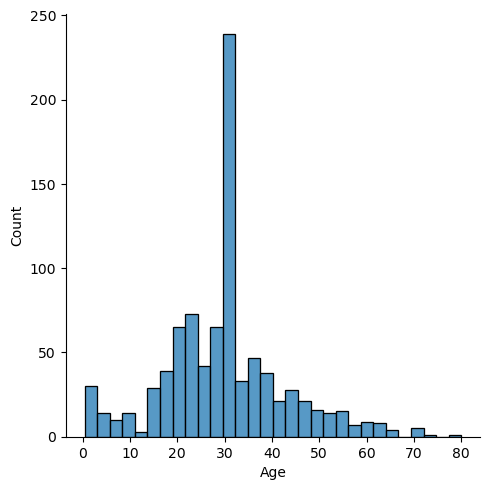

In [15]:
import seaborn as sns

sns.displot(df.Age)

In [16]:
df.Age.min()

0.42

In [17]:
df.Age.max()

80.0

In [18]:
X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

In [32]:
# plt.figure(figsize=(14,4))
# plt.subplot(121)
# sns.kdeplot(X_train['Age'])
# plt.title('Age PDF')

# plt.subplot(122)
# stats.probplot(X_train['Age'], dist="norm", plot=plt)
# plt.title('Age QQ Plot')

# plt.show()

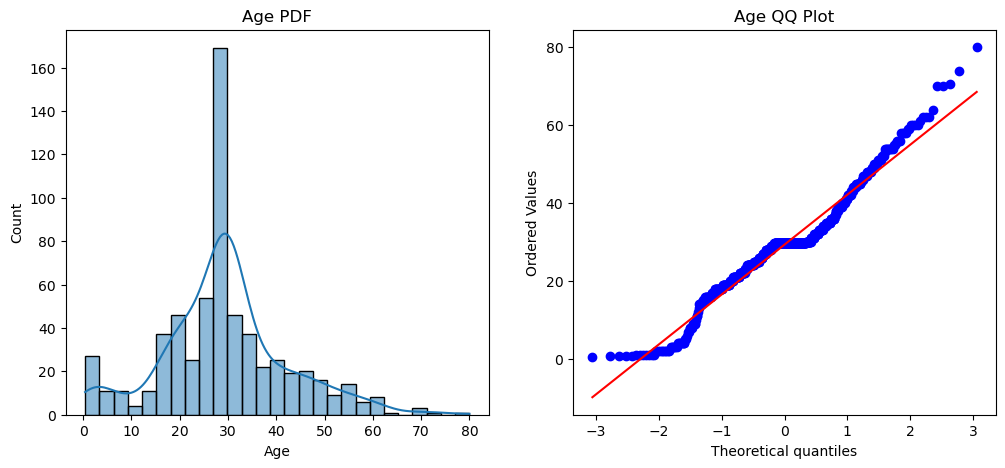

In [30]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
sns.histplot(X_train['Age'],ax=ax1,kde=True)
ax1.set_title("Age PDF")
stats.probplot(X_train['Age'], dist="norm", plot=ax2)
ax2.set_title("Age QQ Plot")


plt.show()

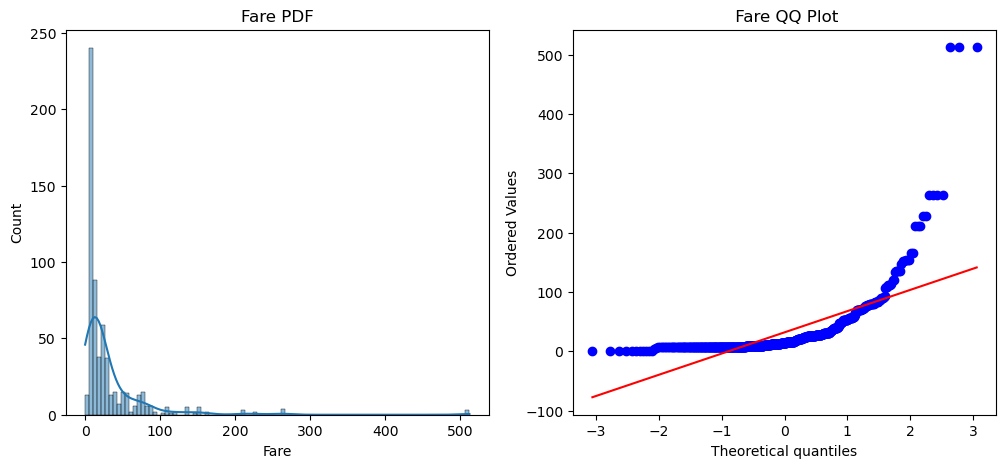

In [31]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
sns.histplot(X_train['Fare'],ax=ax1,kde=True)
ax1.set_title("Fare PDF")
stats.probplot(X_train['Fare'], dist="norm", plot=ax2)
ax2.set_title("Age QQ Plot")


plt.show()

#### Age col seems kind off normally distributed but Fare col is right skewed data .In titanic data we already know most of the people spent less amount on data but few spent too much price for ticket . 

In [33]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [34]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)
    
y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6529850746268657
Accuracy DT 0.6604477611940298


Without applying log transformer we are checking accuracy for both classifier

In [35]:
# Log normal transformer is used for right skewed data so on fare column we will apply function transformer

trf = FunctionTransformer(func=np.log1p)

Difference between np.log and np.log1p is that np.log may give zero value and that will be problem .but np.log1p basically adds +1 lets say x is the value we have to take log so log1p will do np.log1p(x+1) it will add 1 first.

In [36]:
#Applying transformation on both columns
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [37]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)
    
y_pred = clf.predict(X_test_transformed)
y_pred1 = clf2.predict(X_test_transformed)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred1))

Accuracy LR 0.6791044776119403
Accuracy DT 0.6828358208955224


In [40]:
x

,Age,Fare
0,22.000000,7.2500
1,38.000000,71.2833
2,26.000000,7.9250
3,35.000000,53.1000
4,35.000000,8.0500
...,...,...
886,27.000000,13.0000
887,19.000000,30.0000
888,29.699118,23.4500
889,26.000000,30.0000


Basically checking whether my improved results are correct or not of logistic regression as after transforming columns its accuracy increased .SO checking through cross validation ehich basically divides data into n number of data (cv=10) in our case 10 set and then calculates accuracy for each data set and in end calculates the mean of all accuracies .It is more reliable in terms of whether the accuracy actually increased or not

In [41]:
X_transformed = trf.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6509987515605494


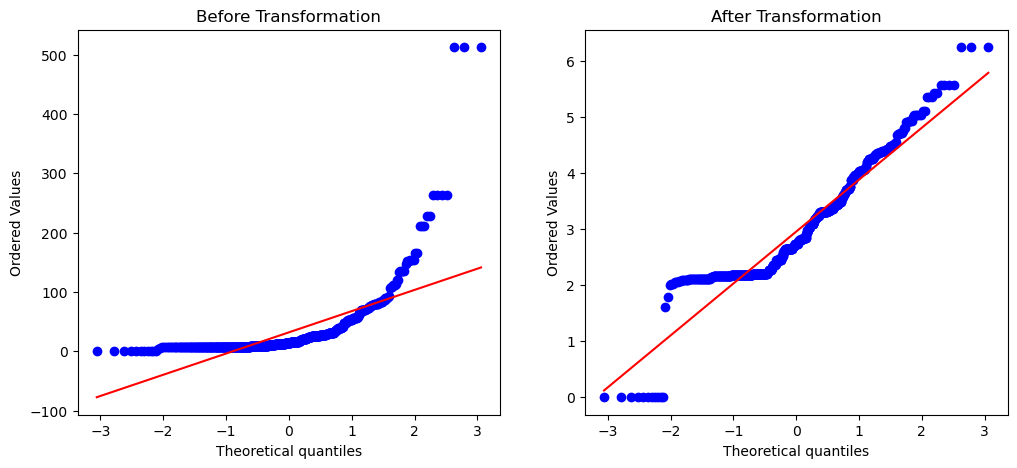

In [42]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
stats.probplot(X_train['Fare'], dist="norm", plot=ax1)
ax1.set_title("Before Transformation")
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=ax2)
ax2.set_title("After Transformation")


plt.show()

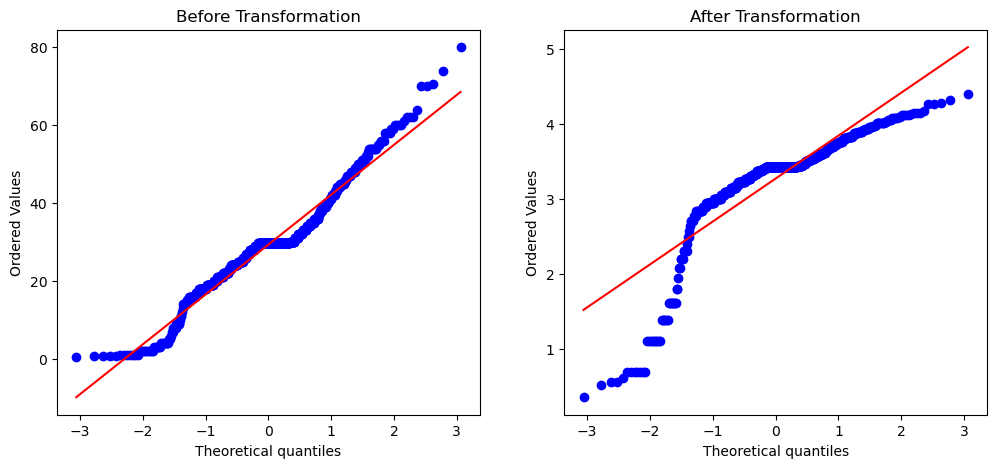

In [43]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
stats.probplot(X_train['Age'], dist="norm", plot=ax1)
ax1.set_title("Before Transformation")
stats.probplot(X_train_transformed['Age'], dist="norm", plot=ax2)
ax2.set_title("After Transformation")


plt.show()

our age data distribution after applying transformer is ruined . as we knew it was not right skewed still we applied .now creating new transformer where we will apply function transformer only on fare column

In [47]:
trf2 = ColumnTransformer([('log',FunctionTransformer(np.log1p),['Fare'])],remainder='passthrough')

X_train_transformed2 = trf2.fit_transform(X_train)
X_test_transformed2 = trf2.transform(X_test)

In [48]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)
    
y_pred = clf.predict(X_test_transformed2)
y_pred2 = clf2.predict(X_test_transformed2)
    
print("Accuracy LR",accuracy_score(y_test,y_pred))
print("Accuracy DT",accuracy_score(y_test,y_pred2))

Accuracy LR 0.664179104477612
Accuracy DT 0.664179104477612


In [49]:
X_transformed2 = trf2.fit_transform(x)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6655680399500624


In [50]:
def apply_transform(transform):
    X = df.iloc[:,1:3]
    y = df.iloc[:,0]
    
    trf = ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    
    X_trans = trf.fit_transform(X)
    
    clf = LogisticRegression()
    
    print("Accuracy",np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))
    
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    stats.probplot(X['Fare'], dist="norm", plot=plt)
    plt.title('Fare Before Transform')

    plt.subplot(122)
    stats.probplot(X_trans[:,0], dist="norm", plot=plt)
    plt.title('Fare After Transform')

    plt.show()

Accuracy 0.6195131086142323


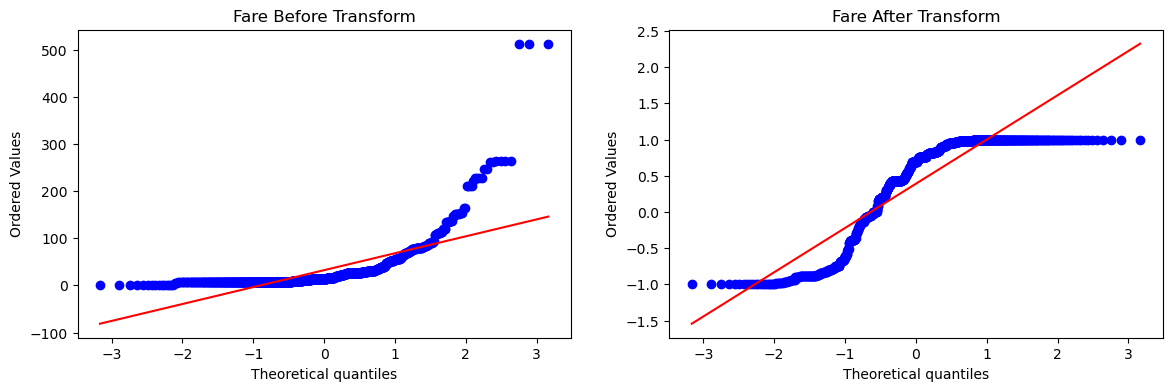

In [51]:
apply_transform(np.sin)


### Reciprocal Transformer (1/x)

In this larger values becomes smaller values and vice versa .sometime useful to get normal distribution.

Accuracy 0.61729088639201


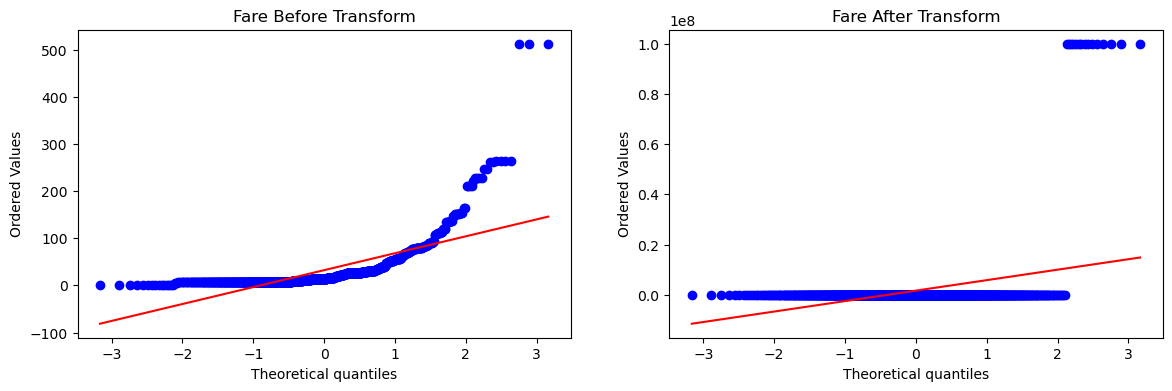

In [59]:
apply_transform(lambda x : 1/(x+0.00000001))

# Adding 0.0001 in x because we are getting error maybe because our denominator is getting zero just to avoid denomintor
# not to be zero adding 0.00001

### Square Transformer (x^^2)
It is used for left skewed data . 

Accuracy 0.6442446941323345


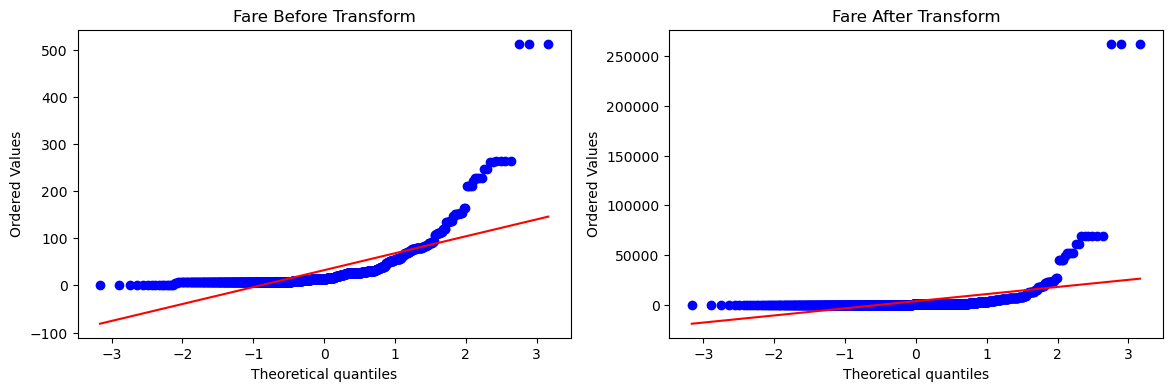

In [54]:
apply_transform(lambda x : x**2)

### Square root (x^^(1/2))
Not that useful we can try using it . Try all transformer and check we gives the best result as the end goal is to get normal distribution of the data set 

Accuracy 0.6589013732833957


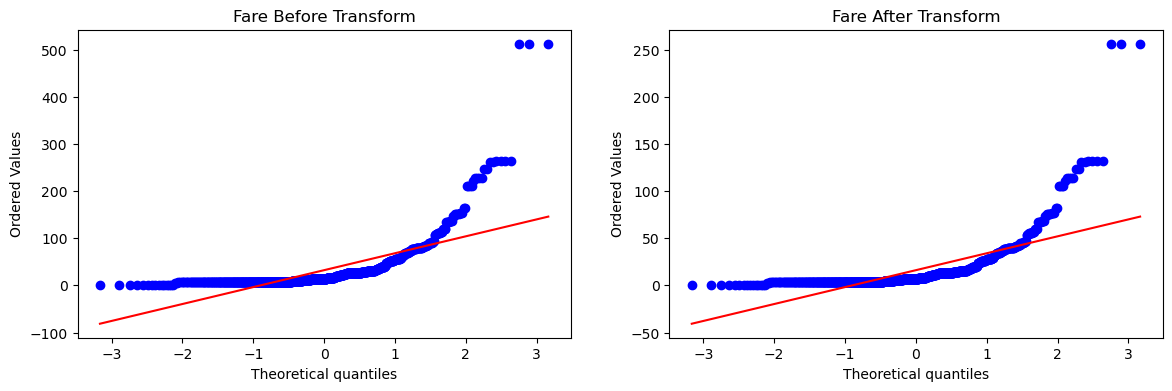

In [55]:
apply_transform(lambda x : x**1/2)